# Medical Insurance Cost Prediction using Multiple Linear Regression

**Assignment 1 – AI/ML**

Dataset: [Medical Cost Personal Insurance Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)

## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [3]:
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']
target_variable = 'charges'

print('Numerical features:', numerical_features)
print('Categorical features:', categorical_features)
print('Target variable:', target_variable)

Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']
Target variable: charges


## Task 2: Data Preprocessing

In [4]:
# Check for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
# Encode categorical variables
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'male': 0, 'female': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)
df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [6]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)

Training set shape: (1070, 8)
Testing set shape: (268, 8)


## Task 3: Model Development

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print('Intercept:', model.intercept_)
coeff_df

Intercept: -11949.810741967713


,Coefficient
age,256.975706
sex,18.591692
bmi,337.092552
children,425.278784
smoker,23651.128856
region_northwest,-370.677326
region_southeast,-657.864297
region_southwest,-809.799354


## Task 4: Model Evaluation

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R2 Score: {r2:.4f}')

Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
R2 Score: 0.7836


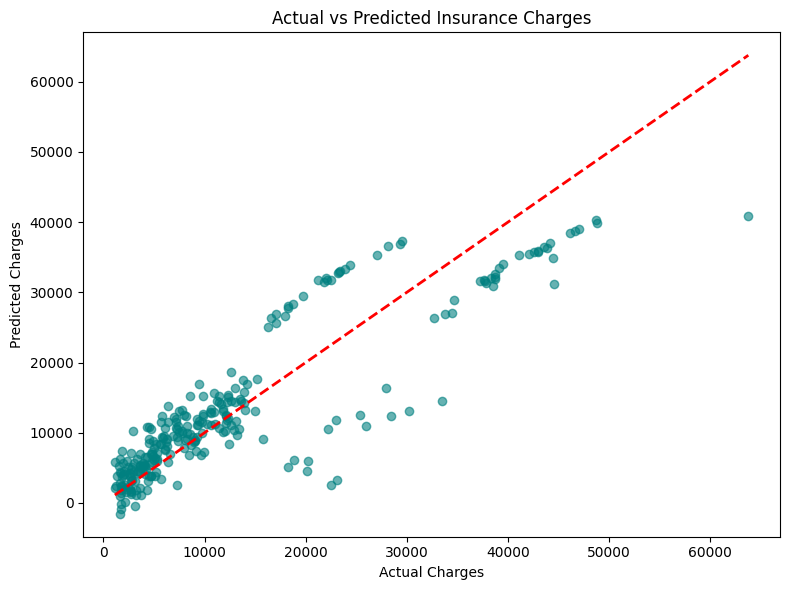

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

### Observations

1. The model achieves a reasonably high R² score, indicating that a large portion of the variance in insurance charges is explained by the chosen features.
2. The `smoker` feature has by far the largest coefficient magnitude, showing that smoking status is the strongest driver of higher insurance charges.
3. The scatter plot shows the model performs well for lower charge values, but tends to underestimate charges for a cluster of high-cost individuals (likely smokers with high BMI), suggesting a non-linear relationship that a linear model cannot fully capture.

## Task 5: Conclusion

This project built a Multiple Linear Regression model to predict medical insurance charges using age, sex, BMI, number of children, smoking status, and region. The model achieved a good fit on the test data, with smoking status emerging as the single most influential factor in determining charges, followed by age and BMI. Region and sex had comparatively minor effects. These findings align with real-world expectations, since smoking and obesity are well-known health risk factors that insurers price heavily into premiums. However, a key limitation of Linear Regression here is its assumption of a linear relationship between features and charges; in reality, the interaction between smoking, BMI, and age produces charges that grow non-linearly, causing the model to underestimate costs for high-risk individuals. A more flexible model, such as a polynomial or tree-based regression, could potentially capture these interactions more accurately.